<a href="https://colab.research.google.com/github/f-Ayuk/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pltpip
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection  import train_test_split
import pickle

In [2]:
df = pd.read_csv("/content/Combined_Flights_2022.csv", on_bad_lines='skip', engine='python')
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,False,False,1133,1123.0,0.0,-10.0,...,1140.0,1220.0,8.0,1245,-17.0,0.0,-2.0,1200-1259,1,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,False,False,732,728.0,0.0,-4.0,...,744.0,839.0,9.0,849,-1.0,0.0,-1.0,0800-0859,2,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1529,1514.0,0.0,-15.0,...,1535.0,1622.0,14.0,1639,-3.0,0.0,-1.0,1600-1659,2,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,False,False,1435,1430.0,0.0,-5.0,...,1446.0,1543.0,4.0,1605,-18.0,0.0,-2.0,1600-1659,2,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1135,1135.0,0.0,0.0,...,1154.0,1243.0,8.0,1245,6.0,0.0,0.0,1200-1259,2,0


In [3]:
df.describe()

,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,...,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
count,335934.000000,328044.000000,328044.000000,328044.000000,327761.000000,327011.000000,327011.000000,335934.000000,327011.000000,335934.000000,...,327870.000000,327870.000000,327761.000000,327761.000000,335934.000000,327011.000000,327011.000000,327011.000000,335934.000000,335934.000000
mean,1323.637104,1330.428921,16.588424,14.093481,1451.861524,16.049824,116.326026,145.978793,140.195403,842.658635,...,16.383969,1352.889807,1448.721288,7.500853,1480.544976,8.502818,0.230873,0.015351,3.847643,0.003173
std,492.787093,509.279390,49.097289,50.038110,549.994296,48.679987,71.771481,73.687027,73.843920,600.985021,...,9.102490,510.833356,545.184442,6.188508,524.335284,51.888000,0.421392,2.474484,2.380290,0.092537
min,5.000000,1.000000,0.000000,-37.000000,1.000000,0.000000,8.000000,22.000000,16.000000,31.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-86.000000,0.000000,-2.000000,1.000000,0.000000
25%,905.000000,907.000000,0.000000,-5.000000,1040.000000,0.000000,62.000000,90.000000,85.000000,399.000000,...,11.000000,923.000000,1037.000000,4.000000,1059.000000,-13.000000,0.000000,-1.000000,2.000000,0.000000
50%,1315.000000,1320.000000,0.000000,-1.000000,1456.000000,0.000000,99.000000,129.000000,123.000000,687.000000,...,14.000000,1334.000000,1453.000000,6.000000,1510.000000,-4.000000,0.000000,-1.000000,3.000000,0.000000
75%,1735.000000,1745.000000,13.000000,13.000000,1916.000000,12.000000,147.000000,177.000000,172.000000,1086.000000,...,19.000000,1759.000000,1911.000000,9.000000,1921.000000,12.000000,0.000000,0.000000,5.000000,0.000000
max,2359.000000,2400.000000,2366.000000,2366.000000,2400.000000,2341.000000,611.000000,621.000000,641.000000,4502.000000,...,175.000000,2400.000000,2400.000000,186.000000,2359.000000,2341.000000,1.000000,12.000000,11.000000,9.000000


In [4]:
print(f"Shape before dropping rows with missing values: {df.shape}")
df.dropna(inplace=True)
print(f"Shape after dropping rows with missing values: {df.shape}")

Shape before dropping rows with missing values: (335934, 61)
Shape after dropping rows with missing values: (327011, 61)


In [5]:
import numpy as np
import pandas as pd

drop_cols = [
    'Cancelled', 'Diverted', 'DepDelay', 'DepDelayMinutes', 'AirTime',
  'CRSElapsedTime', 'ActualElapsedTime', 'Year', 'Quarter',  'DayofMonth',
  'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
  'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline',
  'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline',
  'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState',
  'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID','DestCityMarketID',
  'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups',
  'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [6]:
target= 'ArrDelay'

# Drop rows with missing target
df = df.dropna(subset=[target])

In [7]:
# Convert Categorical to Numeric
df = pd.get_dummies(df, drop_first=True)

Data Visualisation

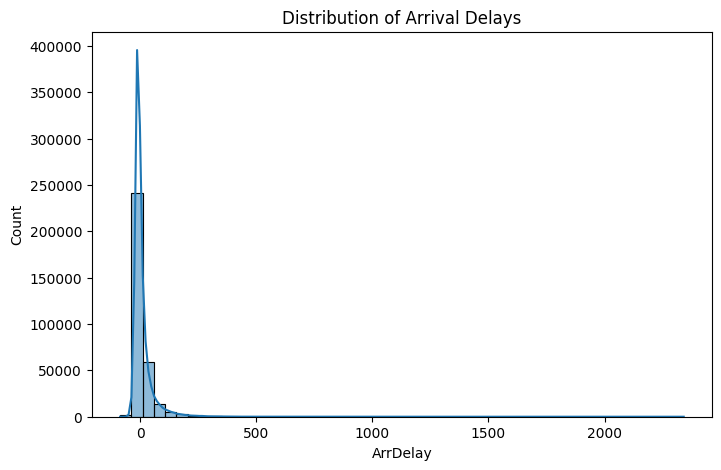

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of arrival delays
plt.figure(figsize=(8,5))
sns.histplot(df['ArrDelay'].dropna(), bins=50, kde=True)
plt.title("Distribution of Arrival Delays")
plt.show()

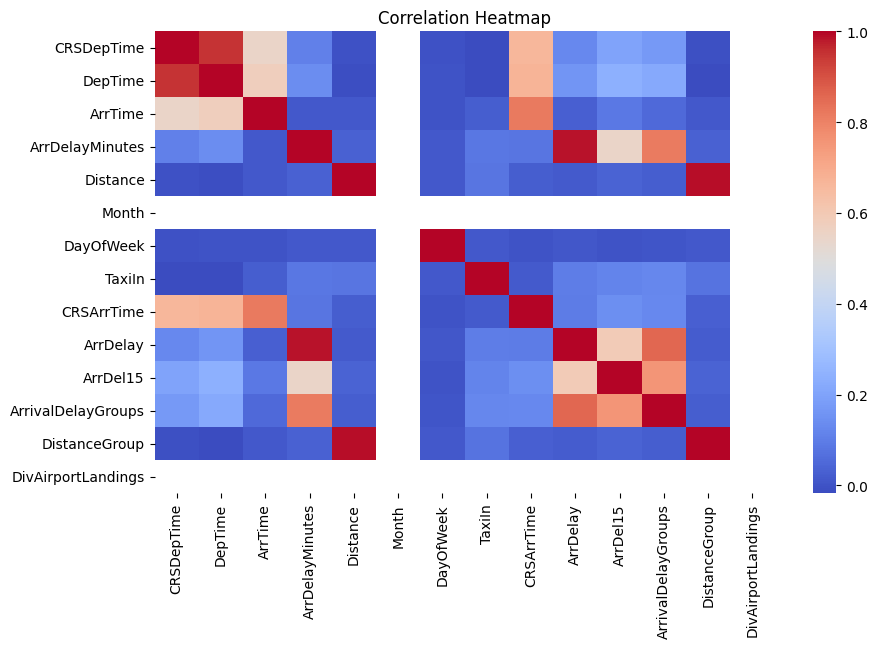

In [9]:
# Correlation heatmap (sample numeric columns)
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

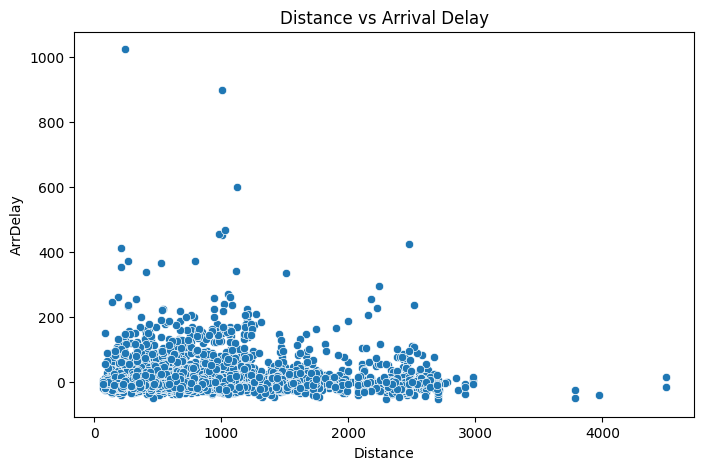

In [10]:
# Delay vs Distance
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance', y='ArrDelay', data=df.sample(5000))
plt.title("Distance vs Arrival Delay")
plt.show()

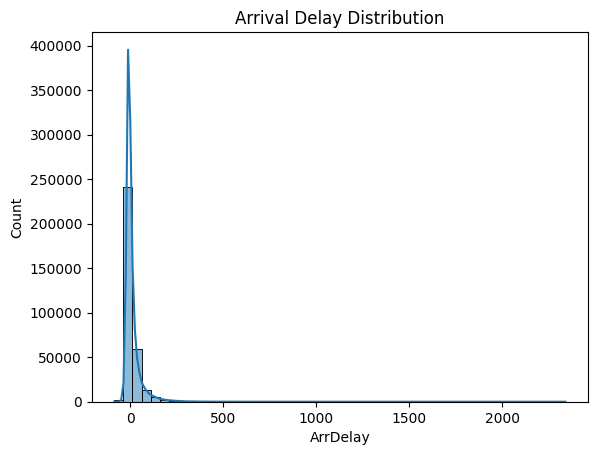

In [11]:
# Visualisation of ArrDelay
sns.histplot(df['ArrDelay'], bins=50, kde=True)
plt.title("Arrival Delay Distribution")
plt.show()

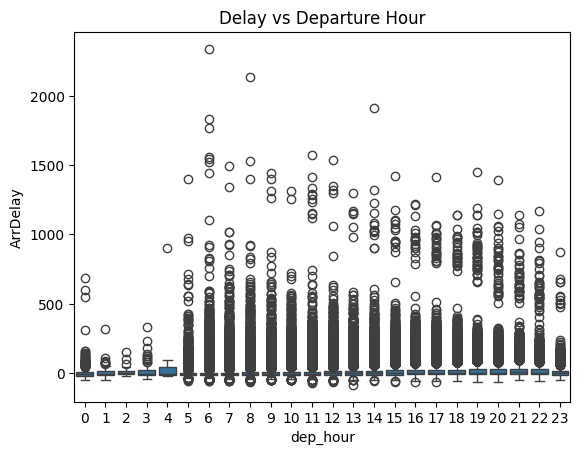

In [12]:
# Create 'dep_hour' column from 'CRSDepTime'
df['dep_hour'] = (df['CRSDepTime'] // 100).astype(int)

# Delay by Hour
sns.boxplot(x='dep_hour', y='ArrDelay', data=df)
plt.title("Delay vs Departure Hour")
plt.show()

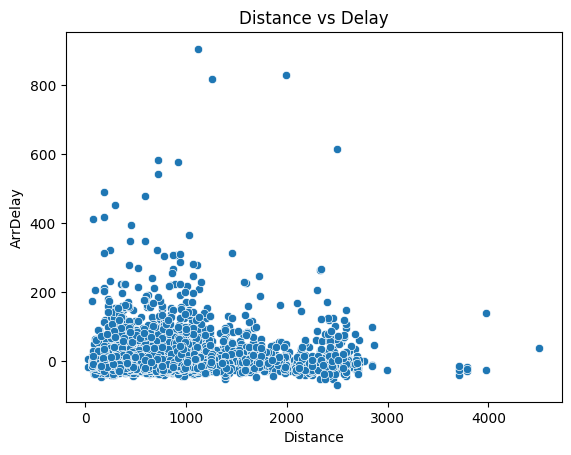

In [13]:
# Delay by Distance
sns.scatterplot(x='Distance', y='ArrDelay', data=df.sample(5000))
plt.title("Distance vs Delay")
plt.show()

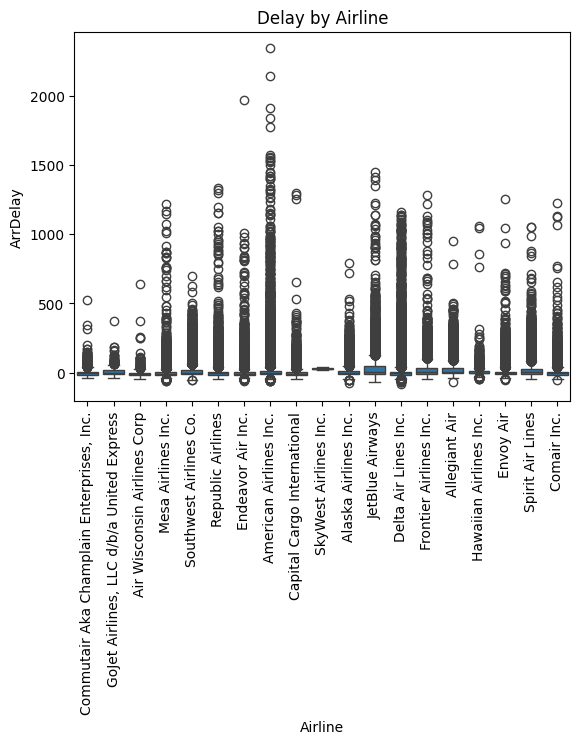

In [14]:
# Delay by Airline
# To visualize 'Delay by Airline', we need the original 'Airline' column.
# Since 'df' has been one-hot encoded, we'll temporarily load data for this plot.

df_temp = pd.read_csv("/content/Combined_Flights_2022.csv", on_bad_lines='skip', engine='python')
df_temp.dropna(subset=['Airline', 'ArrDelay'], inplace=True)

sns.boxplot(x='Airline', y='ArrDelay', data=df_temp)
plt.xticks(rotation=90)
plt.title("Delay by Airline")
plt.show()

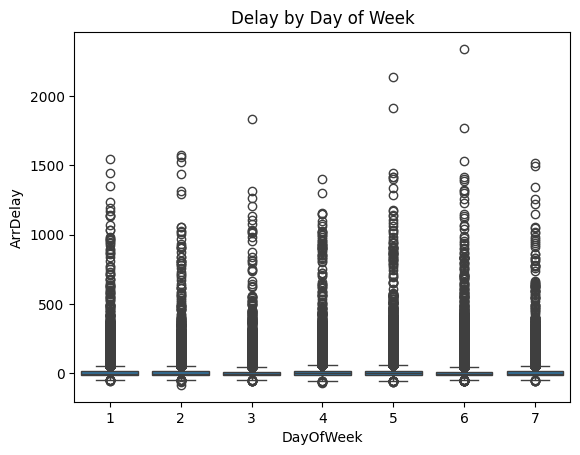

In [15]:
# Delay by Day of the Week
sns.boxplot(x='DayOfWeek', y='ArrDelay', data=df)
plt.title("Delay by Day of Week")
plt.show()

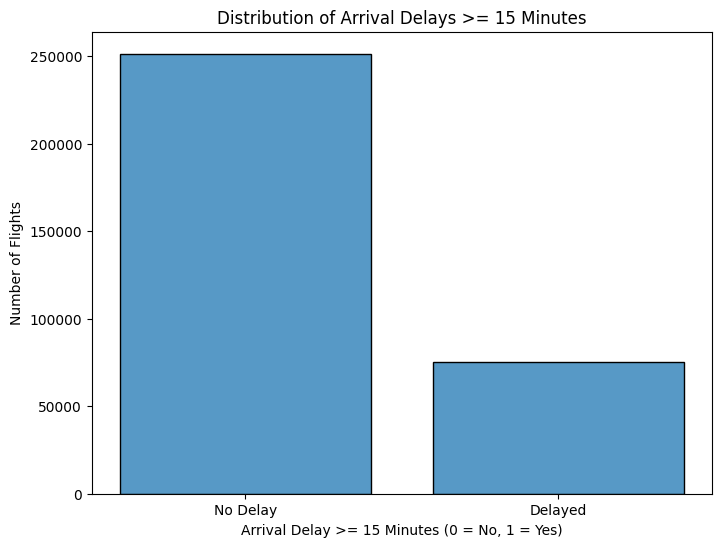

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['ArrDel15'], discrete=True, shrink=0.8, stat='count')
plt.title('Distribution of Arrival Delays >= 15 Minutes')
plt.xlabel('Arrival Delay >= 15 Minutes (0 = No, 1 = Yes)')
plt.ylabel('Number of Flights')
plt.xticks([0, 1], ['No Delay', 'Delayed'])
plt.show()

This histogram shows the count of flights that were delayed by 15 minutes or more (`1`) versus those that were not (`0`) upon arrival.

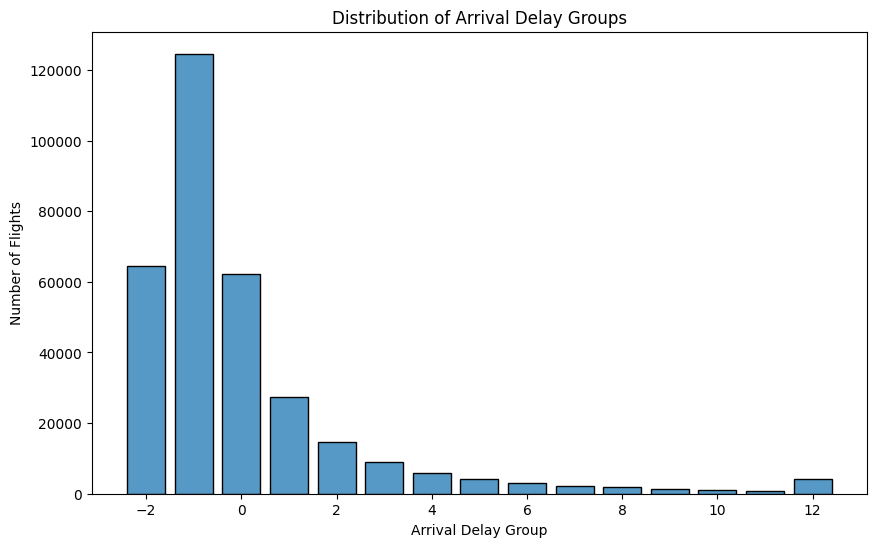

In [17]:
# ArrDelay based on Arrival Group Delay
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['ArrivalDelayGroups'], discrete=True, shrink=0.8, stat='count')
plt.title('Distribution of Arrival Delay Groups')
plt.xlabel('Arrival Delay Group')
plt.ylabel('Number of Flights')
plt.show()

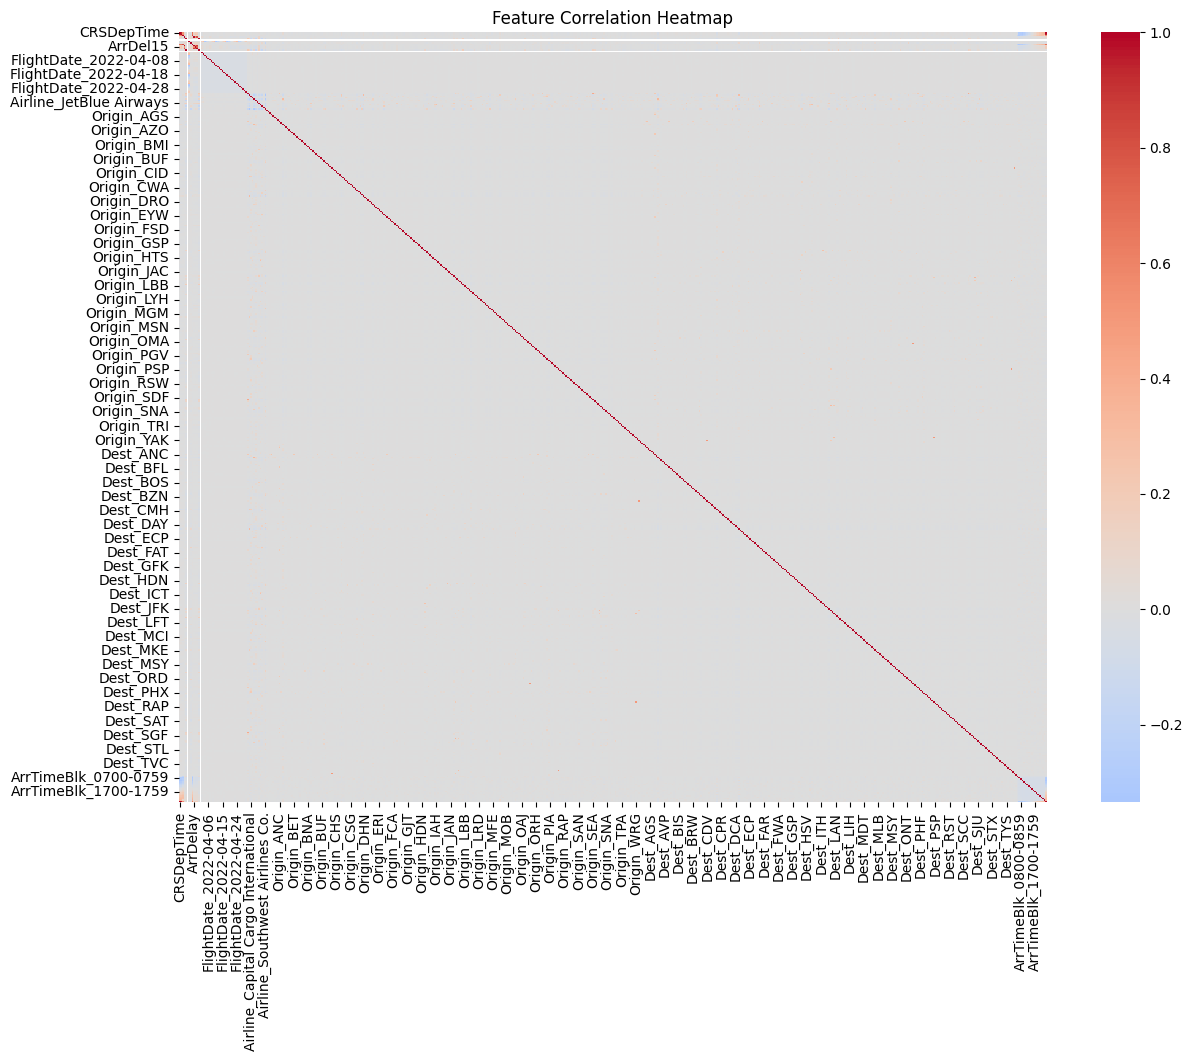

In [18]:
# Heatmap (After Cleaning)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
# Standardization
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[target])
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Splittig the data for the Models (Linear, Decision Tree, Random Forest)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [21]:
# Linear Regression (Gradient Descent)
sgd = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01)

train_losses = []
test_losses = []

for i in range(50):
    sgd.partial_fit(X_train, y_train)

    y_train_pred = sgd.predict(X_train)
    y_test_pred = sgd.predict(X_test)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

In [22]:
## Decision Tree
dt = DecisionTreeRegressor(max_depth=10)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10)

In [23]:
## Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15)

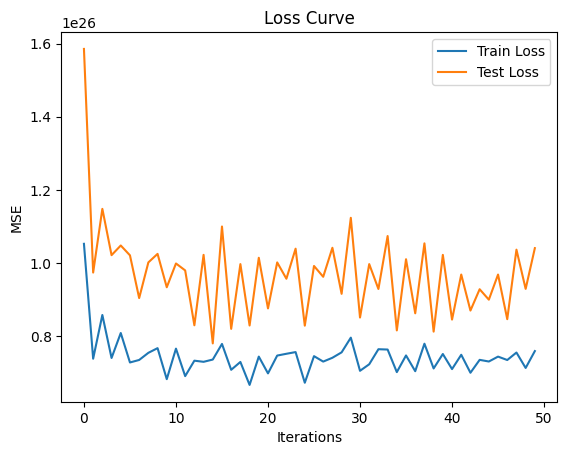

In [24]:
## Plotting Loss Curve
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

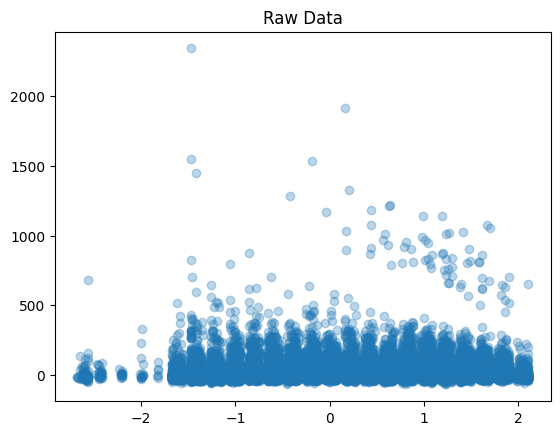

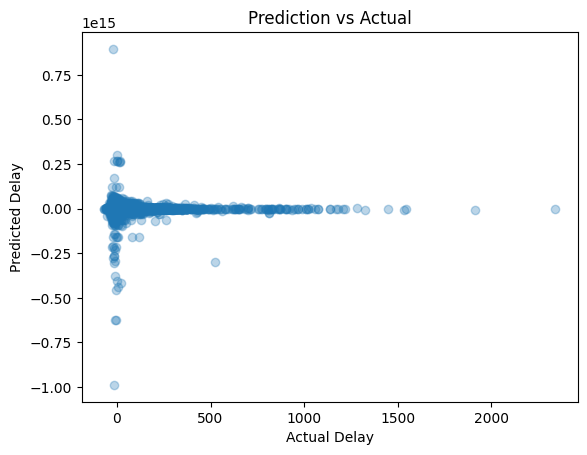

In [25]:
## Scatter Plot (Predictions vs Actual)

# Before (raw)
plt.scatter(X_test[:, 0], y_test, alpha=0.3)
plt.title("Raw Data")
plt.show()

# After (predictions)
y_pred = sgd.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Prediction vs Actual")
plt.show()

In [26]:
## Saving the best model

import joblib

# Evaluate models
models = {
    "SGD": sgd,
    "Decision Tree": dt,
    "Random Forest": rf
}

best_model = None
best_score = float("inf")

for name, model in models.items():
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(f"{name}: {mse}")

    if mse < best_score:
        best_score = mse
        best_model = model

print(f"Best Model: {best_model}")
joblib.dump(best_model, "best_flight_delay_model.pkl")
joblib.dump(scaler, "scaler.pkl")

SGD: 1.0403407619209369e+26
Decision Tree: 14.02091265735915
Random Forest: 14.911101223865844
Best Model: DecisionTreeRegressor(max_depth=10)


['scaler.pkl']

In [27]:
## Prediction Script
import joblib
import numpy as np

# Load model
model = joblib.load("best_flight_delay_model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_delay(input_data):
    input_array = np.array(input_data).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    prediction = model.predict(input_scaled)
    return prediction[0]

# Example usage
sample_input = X.iloc[0].values
print("Predicted Delay:", predict_delay(sample_input))

Predicted Delay: -21.37230830156923


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
